Amishi Gupta

23/CS/048

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [3]:
file_path = '/content/drive/MyDrive/yahoo_data.xlsx'
df = pd.read_excel(file_path)
df.head()

,Date,Open,High,Low,Close*,Adj Close**,Volume
0,"Apr 28, 2023",33797.43,34104.56,33728.40,34098.16,34098.16,354310000
1,"Apr 27, 2023",33381.66,33859.75,33374.65,33826.16,33826.16,343240000
2,"Apr 26, 2023",33596.34,33645.83,33235.85,33301.87,33301.87,321170000
3,"Apr 25, 2023",33828.34,33875.49,33525.39,33530.83,33530.83,297880000
4,"Apr 24, 2023",33805.04,33891.15,33726.09,33875.40,33875.40,252020000


In [6]:
df.columns = df.columns.str.replace(r'[^a-zA-Z0-9 ]', '', regex=True)
df.columns = df.columns.str.strip()
print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')


In [7]:
data = df[['Close']].values
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

In [8]:
def create_dataset(dataset, time_step=60):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)
time_step = 60
X, y = create_dataset(scaled_data, time_step)

In [9]:
#split
train_size = int(len(X) * 0.8)
X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

In [10]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [11]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 154ms/step - loss: 0.0562 - val_loss: 9.6417e-04
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 0.0099 - val_loss: 0.0112
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - loss: 0.0051 - val_loss: 0.0039
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0034 - val_loss: 0.0012
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0027 - val_loss: 9.3593e-04
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.0024 - val_loss: 8.6887e-04
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0023 - val_loss: 8.6185e-04
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0021 - val_loss: 8.6222e-04
Epoch 9/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - loss: 0.0021 - val_loss: 8.3472e-04
Epoch 10/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0020 - val_loss: 8.4722e-04


In [13]:
#predict
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_pred = scaler.inverse_transform(train_pred)
test_pred = scaler.inverse_transform(test_pred)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


In [14]:
#evaluate
train_rmse = np.sqrt(mean_squared_error(y_train_actual, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_actual, test_pred))
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train RMSE: 823.5730627095015
Test RMSE: 529.9729985080595


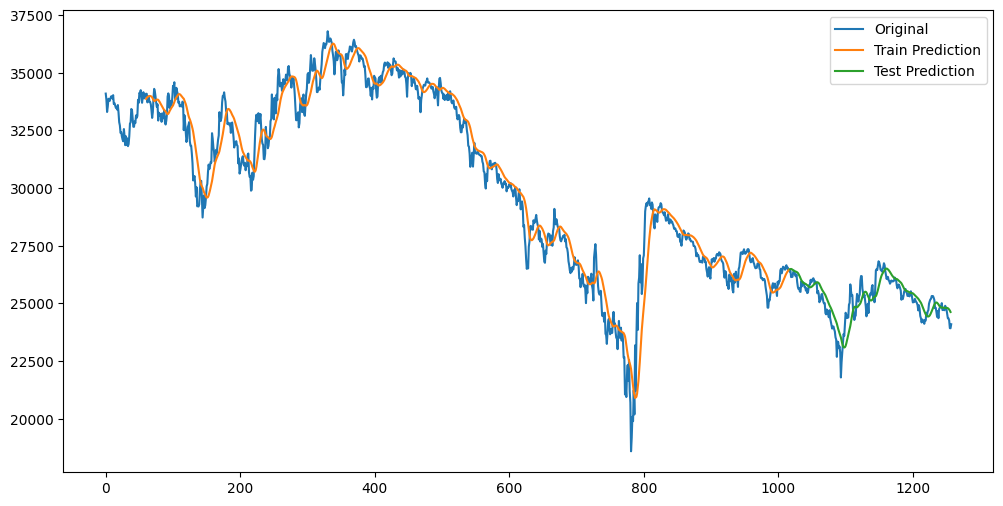

In [16]:
# Create empty arrays
train_plot = np.empty_like(data)
train_plot[:] = np.nan
test_plot = np.empty_like(data)
test_plot[:] = np.nan
train_plot[time_step:time_step + len(train_pred)] = train_pred
test_start = time_step + len(train_pred)
test_plot[test_start:test_start + len(test_pred)] = test_pred

#plot
plt.figure(figsize=(12,6))
plt.plot(data, label='Original')
plt.plot(train_plot, label='Train Prediction')
plt.plot(test_plot, label='Test Prediction')
plt.legend()
plt.show()